
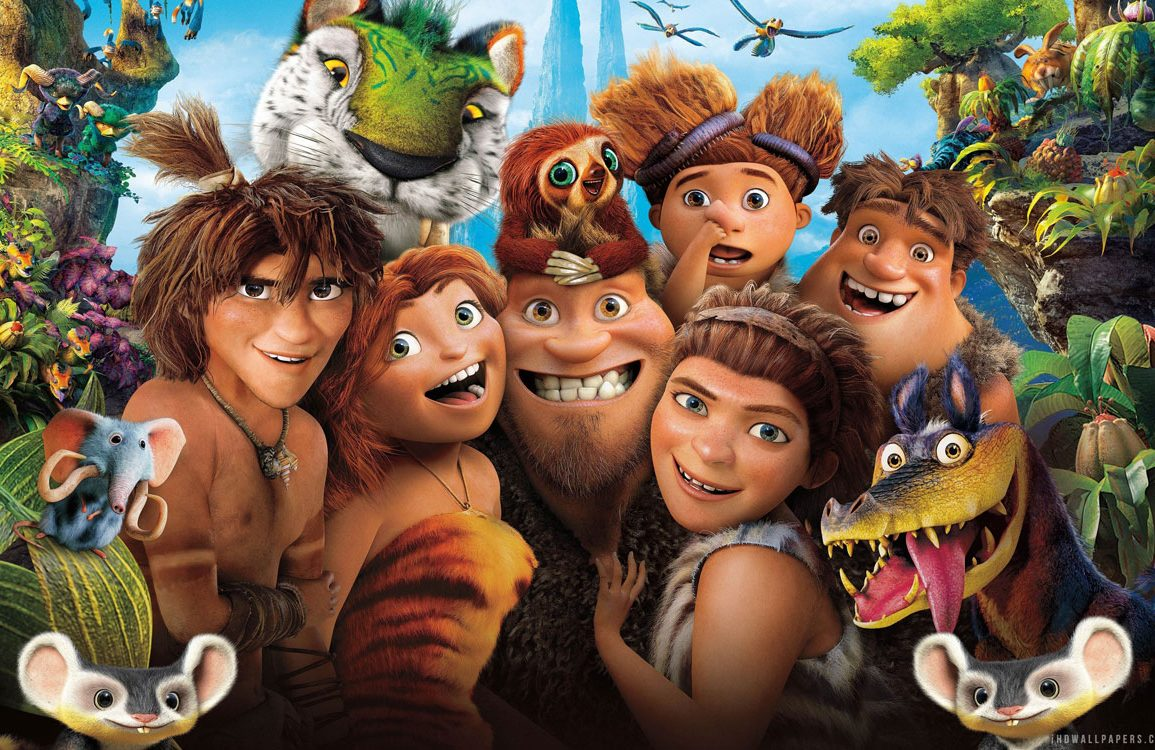


Réference : https://github.com/LisaHJung/Part-1-Intro-to-Elasticsearch-and-Kibana

# CRUD

## Objectifs

Ce TP à pour objetcif de vous familliariser avec Opensearch. Vous apprendrez les bases pour :
* Interroger un index 
* Insérer des documents
* modifier un document dans un index


### API Rest


On utilisera les API REST pour la plupart des opérations sur OpenSearch. La description des API est disponible ici :

https://opensearch.org/docs/2.8/api-reference/index/

Si vous souhaitez utiliser la commande curl pour utiliser l'API il vous suffira de respecter la syntaxe suivante :

curl -X<VERB> '<PROTOCOL>://<HOST>/<API>/<parameter>?<QUERY_STRING>' -d '<BODY>' 

L'exemple ci-dessous utilise l'API `_cat` pour afficher la liste des indexes disponibles :

In [3]:
!curl  --insecure -XGET  -u "admin:admin" "http://localhost:9200/_cat/indices"

green  open .plugins-ml-config           Yion353BSuGPMDkDEQS2nQ 1 0 1 0    4kb    4kb
green  open .ql-datasources              z2OK3_LZQpeD_b-Hvd7ZQw 1 0 0 0   208b   208b
yellow open mon_index                    phVIEi_rS5Kcz45v9mlz0A 1 2 0 0   208b   208b
green  open top_queries-2026.06.03-14687 ez5wCcQdRne3hB2iLywZDg 1 0 3 0 88.8kb 88.8kb
green  open .kibana_1                    nkhXSZUaRuOklcpDq7txxQ 1 0 1 0  5.2kb  5.2kb


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100    430 100    430   0      0  15681      0                              0
100    430 100    430   0      0  15652      0                              0
100    430 100    430   0      0  15614      0                              0


Pour faciliter la compréhension des TP, on utilisera l'interface graphique d'`Opensearch Dashboard`  via `Dev Tools`

### Connexion au cluster OpenSearch

Pour accéder à `Opensearch Dashboard` vous connaissez déjà l'adresse (RDV sur le port 5601)

```{note}
Le chargement du dashboard peut prendre quelques minutes avant que l'interface graphique soit opérationnelle.
Vous pouvez consulter les logs des containers afin de vérifier le statut de vos containers.

```

Indiquer le login et mot de passe admin :

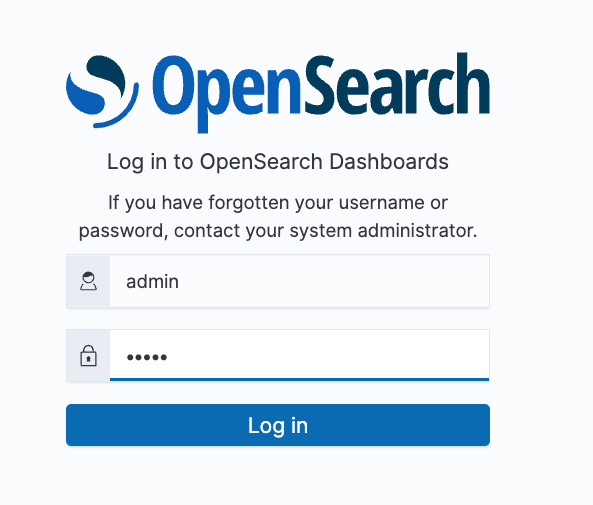

Dans le menu de gauche, `Opensearch Dashboard` propose un outil de requêtage `dev tools` à partir du quel vous pourrez exploiter l'API Rest.


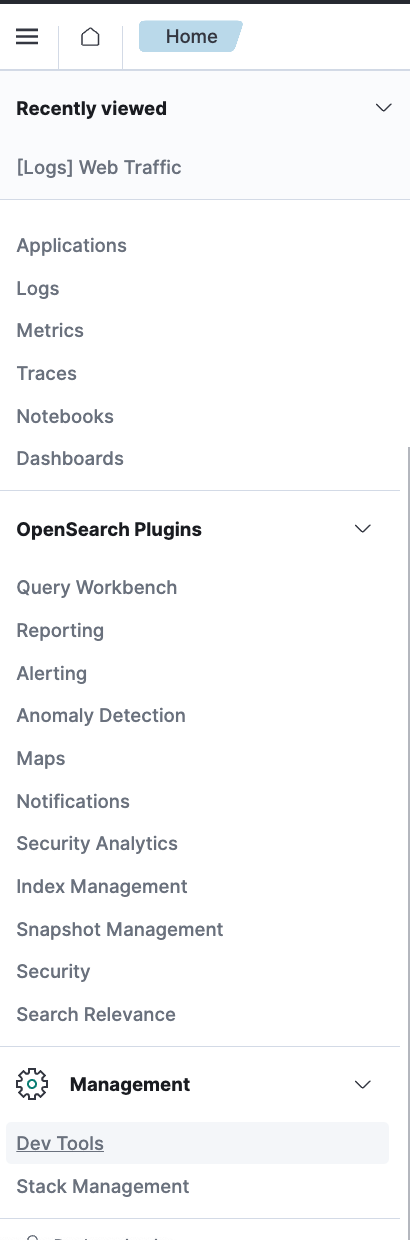

L'utilisation de `Dev Tools`, nous permet des simplifier l'utilisation des API, sous la forme :

Reprenons notre exemple précédent avec l'API `_cat` :


#### Utiliser l'API `_cluster` à partir de `Dev tools` pour vérifier l'état de votre cluster ainsi que le nombre de nodes ?

```{note}
L'autocomplétion est activé sur Dev Tools, il est assez intuitif de repérer les paramètres possibles. 

```


{
  "cluster_name": "opensearch",
  "status": "yellow",
  "timed_out": false,
  "number_of_nodes": 1,
  "number_of_data_nodes": 1,
  "discovered_master": true,
  "discovered_cluster_manager": true,
  "active_primary_shards": 6,
  "active_shards": 6,
  "relocating_shards": 0,
  "initializing_shards": 0,
  "unassigned_shards": 2,
  "delayed_unassigned_shards": 0,
  "number_of_pending_tasks": 0,
  "number_of_in_flight_fetch": 0,
  "task_max_waiting_in_queue_millis": 0,
  "active_shards_percent_as_number": 75
}

#### Pourriez vous jeter un oeil aux statistiques des nodes avec l'API _nodes  ?

{
  "_nodes": {
    "total": 1,
    "successful": 1,
    "failed": 0
  },
  "cluster_name": "opensearch",
  "nodes": {
    "TcD275qRRECzkJmgc8Yvqg": {
      "timestamp": 1780508012898,
      "name": "DESKTOP-T9PL0M1",
      "transport_address": "127.0.0.1:9300",
      "host": "127.0.0.1",
      "ip": "127.0.0.1:9300",
      "roles": [
        "cluster_manager",
        "data",
        "ingest",
        "remote_cluster_client"
      ],
      "attributes": {
        "shard_indexing_pressure_enabled": "true"
      },
      "indices": {
        "docs": {
          "count": 469,
          "deleted": 18
        },
        "store": {
          "size_in_bytes": 398473,
          "reserved_in_bytes": 0
        },
        "indexing": {
          "index_total": 40,
          "index_time_in_millis": 122,
          "index_current": 0,
          "index_failed": 0,
          "delete_total": 0,
          "delete_time_in_millis": 0,
          "delete_current": 0,
          "noop_update_total": 0,
          "is_throttled": false,
          "throttle_time_in_millis": 0,
          "doc_status": {
            "2xx": 40
          }
        },

### Création de notre premier index 

Commençons par créer un index :

Reponse : 
{
  "acknowledged": true,
  "shards_acknowledged": true,
  "index": "myindex"
}

C'est tout ! et oui c'est tout simple vous trouvez pas ?



## Découverte des opérations CRUD 

### C - Insertion d'un document

Pour identifier un document, OpenSearch se base sur 2 éléments :

* l'index
* son id

Pour insérer un nouveau document dans notre surperbe index `myindex`, on utilise l'API document :

[https://opensearch.org/docs/2.8/api-reference/document-apis/index/](https://opensearch.org/docs/2.8/api-reference/document-apis/index/)

#### En analysant la sortie de la commande, décriver le contenu  ?

Si vous êtes fénénant comme moi on peut utiliser la méthod POST qui générera un identifiant pour nous 

Jetons un oeil aux documents stocké dans notre index myindexes 


#### Que constatez vous sur l'identifiant de notre second document ?

### R - Lecture des index

Pour lire un document, on utilise le verbe GET :

### rechecher le document identifier par l'id 1 ?

En tout cas je vous invites à jouer avec l'API `_cat`, elle permet d'avoir un rapide coups d'oeil sur contenu de votre cluster :

[https://opensearch.org/docs/2.8/api-reference/cat/index/](https://opensearch.org/docs/2.8/api-reference/cat/index/)


#### A partir de l'API _cat, déterminer les IP des noeuds et  le nombre d'index ?


La lecture est bien plus complexe, nous aborderons ce sujet dans un autre TP mais il fallait bien commencer par quelque chose non :-) 

### U - Mise à jour d'un document


Pour mettre à jour un document on utilise POST  : 

#### Que constatez vous concernant l'opération menée par Opensearch ?


### D - Suppression d'un document

Pour supprimer un documents on utilisera la méthode DELETE :


Supprimons alors notre document 1 :

DELETE /myindex/_doc/1

#### En analysant la sortie de la commande, décriver le contenu  ?

<font color='red'>Que se passe-'il si une action échoue </font> 

Si je réessaie de supprimer le doc supprimer par exemple j'obtiens une erreur 404 : 
{
  "_index": "myindex",
  "_id": "1",
  "_version": 4,
  "result": "not_found",
  "_shards": {
    "total": 2,
    "successful": 1,
    "failed": 0
  },
  "_seq_no": 4,
  "_primary_term": 1
}

Opensearch n'est pas transactionnel par conséquent si une action échoue cela n'a pas d'incidence sur les autres 

<font color='red'>Supprimer l'index website</font>

## _bulk

La commande `_bulk` permet de faire du `CUD` (CRUD sans le R) donc du CREATE, UPDATE et DELETE.
Vous pouvez ingérer plusieurs documents en une seule fois sur plusieurs index, l'insertion de plusieurs documents est regroupée en une seule commande et offre de meilleurs performances à l'insertion. 

Le descriptif de `_bulk` est disponible ici :

https://opensearch.org/docs/latest/api-reference/document-apis/bulk/


Exécuter le `_bulk` suivant :


### Que constatez vous ?

## A vous de jouer !

### Créez un index appelé travel

### Choisissez 2 destinations de voyage de rêve. Pour chaque destination, indexez un document contenant le nom et le pays.

### Lire (GET) chaque document pour vérifier le contenu du document.

### Mettre à jour un des 2 voyages en y ajoutant un champs description et le prix du voyage :

### Lisez (GET) le document mis à jour pour vous assurer que le champ a été mis à jour.


### Supprimer un des 2 voyages :

### Lister tous les documents de l'index `travel`. C'est un excellent moyen de vérifier si toutes les opérations CRUD que vous avez effectuées jusqu'à présent ont fonctionné !

Pour les plus motivés, utiliser l'API _bulk pour effectuer l'ensemble des opérations précédentes :